In [8]:
import utils
from utils import DataGenerator, Reservoir

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [9]:
# std is 1
def U(q, sigma=1):
    C = 1/2 * np.log(2*np.pi*sigma**2)
    return q**2 / (2*sigma**2) + C

def grad_U(q, sigma=1):
    return q / (sigma**2)

def K(p):
    return p**2 / 2

def H(q, p):
    return U(q) + K(p)

In [10]:
# Leapfrog
def leapfrog(q, p, epsilon, L):
    q_new = q
    p_new = p

    for t in range(L):
        p_new = p_new - 0.5 * epsilon * grad_U(q_new)
        q_new = q_new + epsilon * p_new
        p_new = p_new - 0.5 * epsilon * grad_U(q_new)

    return q_new, p_new

def hmc_sampler(num_samples, inti_q, epsilon, L):
    samples = torch.zeros(num_samples)
    q_current = init_q
    delta_Hs = []
    accepted = 0
    acceptance_rates = []

    for i in range(num_samples):
        p_current = torch.randn(1)
        q_proposed, p_proposed = leapfrog(q_current, p_current, epsilon, L)
        H_start = H( q_current, p_current )
        H_end = H( q_proposed, p_proposed )

        delta_H = H_end - H_start
        log_alpha = min(0, -delta_H)

        delta_Hs.append(delta_H)

        if torch.log(torch.rand(1)) < log_alpha:
            q_current = q_proposed
            accepted += 1
        acceptance_rate = accepted / num_samples
        acceptance_rates.append(acceptance_rate)

        samples[i] = q_current

    return samples, acceptance_rate, delta_Hs

Integration Step Size (epsilon): 0.01
Trajectory Length (L): 15
Acceptance Rate: 1.0000
Estimated Mean: -0.1001
Estimated Variance: 0.5242


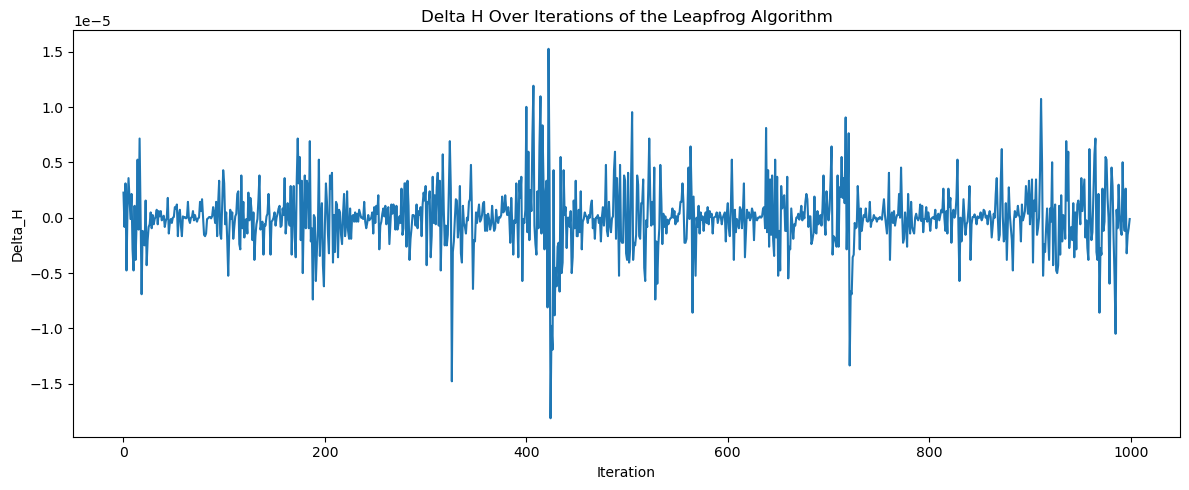

In [11]:
num_samples = 1000
init_q = torch.tensor([1.0])
step_size = 0.01
trajectory_L = 15

samples, acc_rate, delta_Hs = hmc_sampler(num_samples, init_q, step_size, trajectory_L)

print(f"Integration Step Size (epsilon): {step_size}")
print(f"Trajectory Length (L): {trajectory_L}")
print(f"Acceptance Rate: {acc_rate:.4f}")
print(f"Estimated Mean: {samples.mean().item():.4f}")
print(f"Estimated Variance: {samples.var().item():.4f}")

plt.figure(figsize=(12,5))
plt.plot(range(num_samples), delta_Hs)
plt.ylabel("Delta_H")
plt.xlabel("Iteration")
plt.title("Delta H Over Iterations of the Leapfrog Algorithm")
plt.tight_layout()
plt.show()

In [12]:
def U_ll(q, mu, sigma):
    C = 0.5 * np.log(2 * np.pi * sigma**2)
    return C + 0.5 * ((mu - q)**2 / sigma**2 + q**2)

def grad_U_ll(q, mu, sigma):
    return -(mu - q) / (sigma**2) + q

def K(p):
    return 0.5 * p**2

def H_ll(q, p, mu, sigma):
    return U_ll(q, mu, sigma) + K(p)

def leapfrog(q, p, epsilon, L, mu, sigma):
    q_new = q
    p_new = p
    
    # Half step momentum
    p_new = p_new - 0.5 * epsilon * grad_U_ll(q_new, mu, sigma)
    
    for t in range(L - 1):
        # Full step position
        q_new = q_new + epsilon * p_new
        # Full step momentum
        p_new = p_new - epsilon * grad_U_ll(q_new, mu, sigma)
        
    # Final full step position
    q_new = q_new + epsilon * p_new
    # Final half step momentum
    p_new = p_new - 0.5 * epsilon * grad_U_ll(q_new, mu, sigma)
    
    return q_new, -p_new

def hmc_sampler(num_samples, init_q, epsilon, L, mu, sigma):
    samples = np.ones(num_samples+1)
    q_current = init_q
    samples[0] = init_q
    delta_Hs = []
    accepted = 0
    p_set = np.zeros(num_samples+1)

    for i in range(num_samples):
        p_current = np.random.randn()
        
        # Suppress overflow warnings for the instability visualization
        with np.errstate(over='ignore', invalid='ignore'):
            q_proposed, p_proposed = leapfrog(q_current, p_current, epsilon, L, mu, sigma)
            H_start = H_ll(q_current, p_current, mu, sigma)
            H_end = H_ll(q_proposed, p_proposed, mu, sigma)
            
            delta_H = H_end - H_start
        
        delta_Hs.append(delta_H)
        
        # Handle NaNs from divergence
        if np.isnan(delta_H):
            log_alpha = -np.inf
        else:
            log_alpha = min(0.0, -delta_H)

        if np.log(np.random.rand()) < log_alpha:
            q_current = q_proposed
            accepted += 1
            
        samples[i+1] = q_current
        p_set[i+1] = p_current

    acc_rate = accepted / num_samples
    return samples, acc_rate, np.array(delta_Hs), p_set

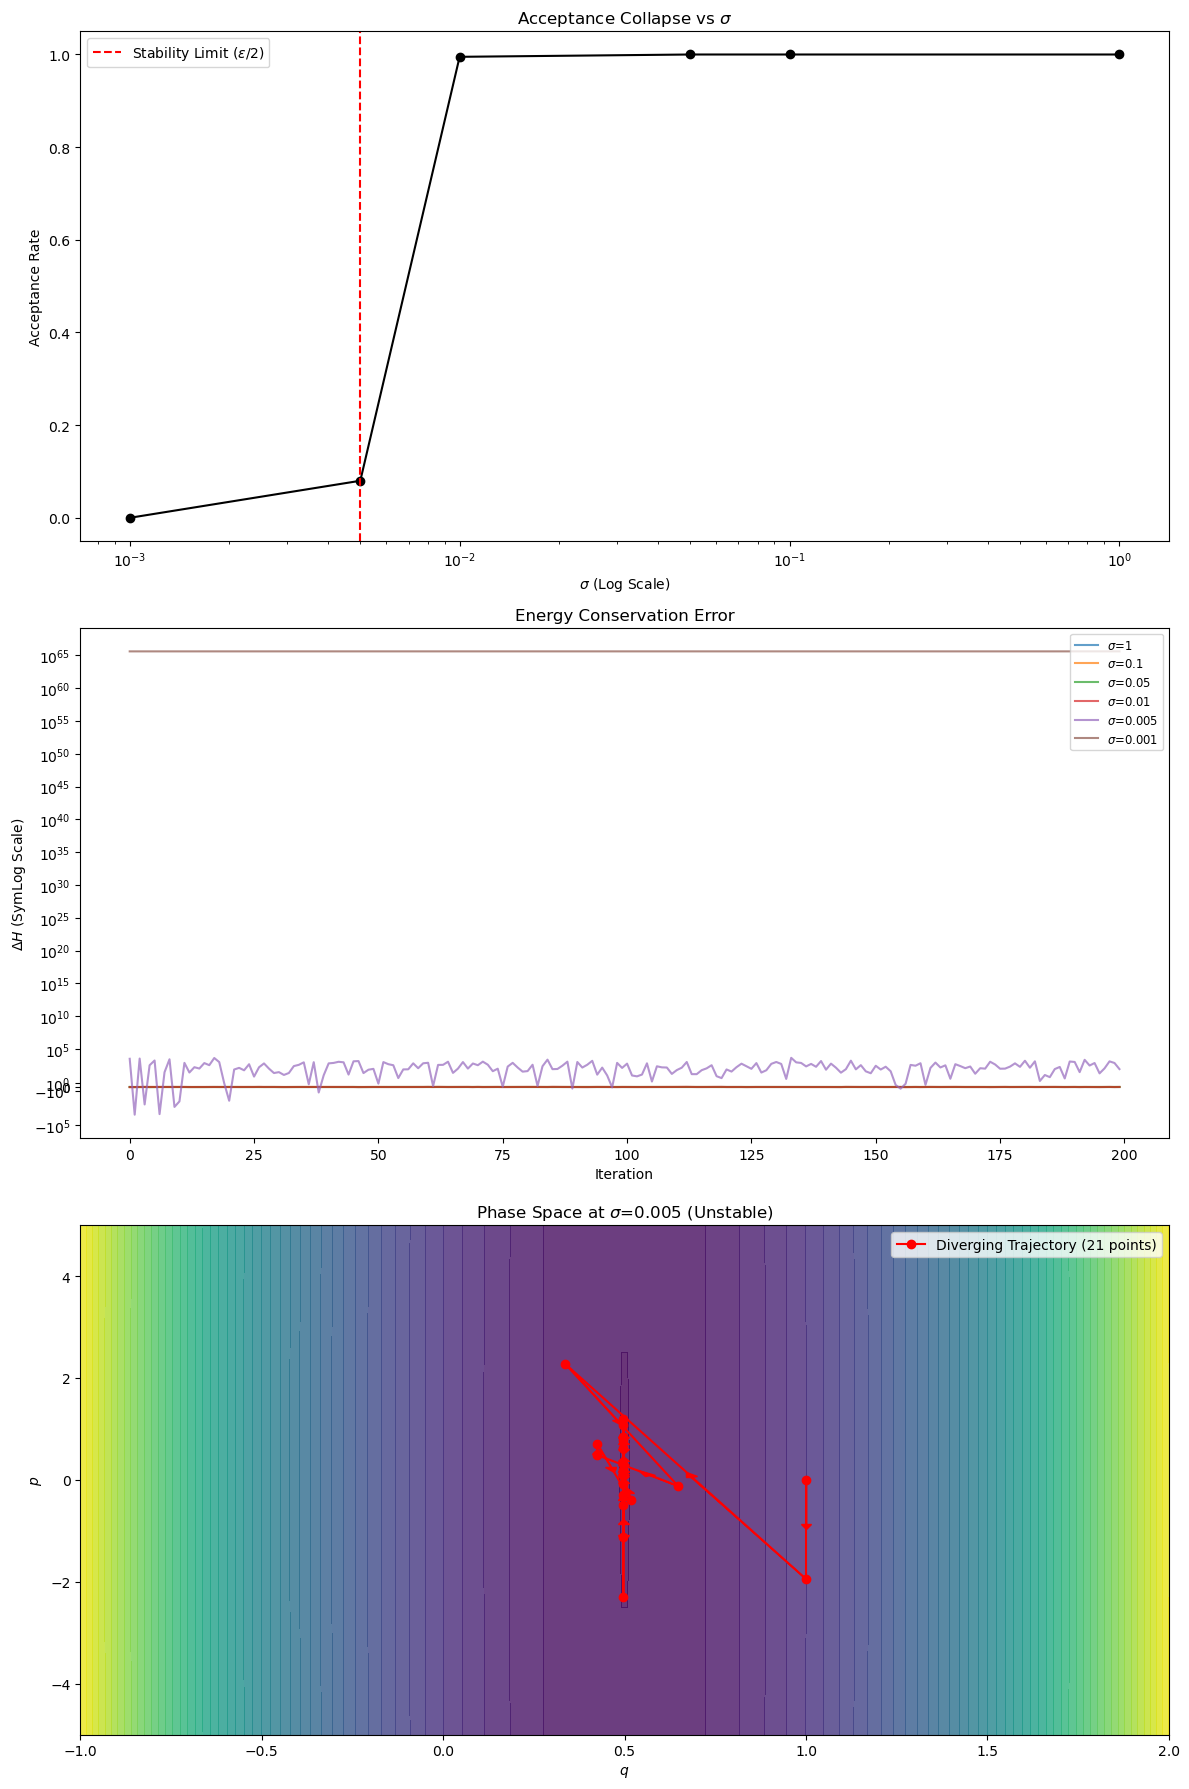

In [13]:
mu = 0.5
init_q = 1.0
step_size = 0.01
L = 15
num_samples = 200
sigma_values = [1, 0.1, 0.05, 0.01, 0.005, 0.001]
phase_points = 21

acc_rates = []
median_delta_Hs = []

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

for sig in sigma_values:
    samples, acc_rate, delta_Hs, p_samples = hmc_sampler(num_samples, init_q, step_size, L, mu, sig)
    acc_rates.append(acc_rate)
    
    # Filter NaNs for plotting median
    valid_delta_Hs = delta_Hs[~np.isnan(delta_Hs)]
    med_dh = np.median(np.abs(valid_delta_Hs)) if len(valid_delta_Hs) > 0 else np.inf
    median_delta_Hs.append(med_dh)
    
    axes[1].plot(range(num_samples), delta_Hs, label=f'$\sigma$={sig}', alpha=0.7)

# 1. Acceptance Rate Degradation
axes[0].plot(sigma_values, acc_rates, marker='o', color='black')
axes[0].axvline(step_size/2, color='red', linestyle='--', label='Stability Limit ($\epsilon/2$)')
axes[0].set_xscale('log')
axes[0].set_xlabel('$\sigma$ (Log Scale)')
axes[0].set_ylabel('Acceptance Rate')
axes[0].set_title('Acceptance Collapse vs $\sigma$')
axes[0].legend()

# 2. Delta H Explosion
axes[1].set_yscale('symlog')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('$\Delta H$ (SymLog Scale)')
axes[1].set_title('Energy Conservation Error')
axes[1].legend(loc='upper right', fontsize='small')

# 3. Phase Space Divergence (for sigma = epsilon / 2)
sig_unstable = 0.005
q_samples, _, _, p_samples = hmc_sampler(20, init_q, step_size, L, mu, sig_unstable)

q_grid = np.linspace(-1, 2, 200)
p_grid = np.linspace(-5, 5, 200)
Q, P = np.meshgrid(q_grid, p_grid)
H_grid = H_ll(Q, P, mu, sig_unstable)

axes[2].contourf(Q, P, H_grid, levels=50, cmap='viridis', alpha=0.8)
axes[2].plot(
    q_samples[:phase_points], p_samples[:phase_points], 
    marker='o', color='red', linestyle='-', label=f'Diverging Trajectory ({phase_points} points)'
    )
for q1, p1, q2, p2 in zip(
    q_samples[:-1][:phase_points], p_samples[:-1][:phase_points], 
    q_samples[1:][:phase_points], p_samples[1:][:phase_points]
    ):
    dq = q2 - q1
    dp = p2 - p1
    axes[2].arrow(
        q1, p1, dq / 2, dp / 2, 
        head_width=0.03, head_length=0.1, 
        fc='red', ec='red',
        length_includes_head=True, animated=True, snap=True
    )
axes[2].set_xlabel('$q$')
axes[2].set_ylabel('$p$')
axes[2].set_title(f'Phase Space at $\sigma$={sig_unstable} (Unstable)')
axes[2].legend()

plt.tight_layout()
plt.show()

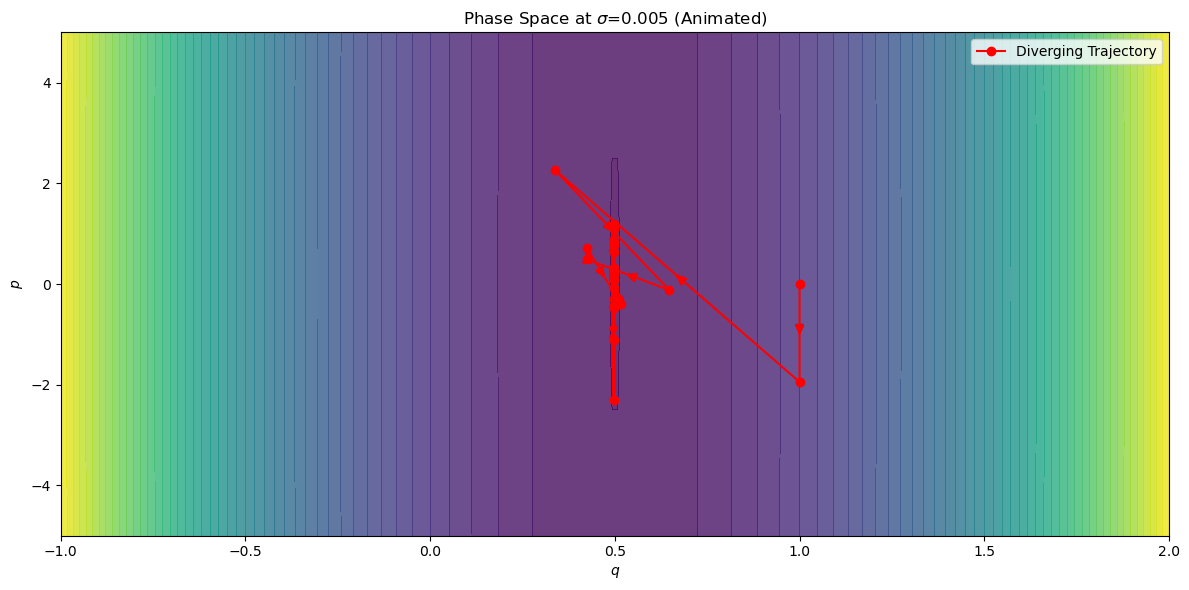

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Phase Space Divergence (Animated)
ax.contourf(Q, P, H_grid, levels=50, cmap='viridis', alpha=0.8)
ax.set_xlabel('$q$')
ax.set_ylabel('$p$')
ax.set_title(f'Phase Space at $\sigma$={sig_unstable} (Animated)')

# Initialize empty elements for the animation
line, = ax.plot([], [], marker='o', color='red', linestyle='-', label='Diverging Trajectory')
ax.legend()

def init():
    line.set_data([], [])
    return line,

def animate(i):
    # Define current segment
    line.set_data(q_samples[:i+1], p_samples[:i+1])
    
    # Clear previous arrows
    [p.remove() for p in reversed(ax.patches)]
    
    # Draw arrows up to the current frame
    for j in range(i):
        q1, p1 = q_samples[j], p_samples[j]
        q2, p2 = q_samples[j+1], p_samples[j+1]
        
        dq = q2 - q1
        dp = p2 - p1
        
        # Calculate midpoint
        mid_q = q1 + dq / 2
        mid_p = p1 + dp / 2
        
        # Directional arrow at segment midpoint
        ax.annotate('', xy=(mid_q + dq*0.01, mid_p + dp*0.01), 
                         xytext=(mid_q - dq*0.01, mid_p - dp*0.01),
                         arrowprops=dict(arrowstyle="->", color='red', lw=2))
    return line,


anim = animation.FuncAnimation(fig, animate, frames=len(q_samples), init_func=init, blit=False, interval=400)
anim.save('leap-frog_anim.mp4', writer='ffmpeg')
plt.tight_layout()
plt.show()